In [43]:
from common_utils.utils import chunks
from tqdm import tqdm
from matplotlib import pyplot as plt
from pylab import rcParams
import seaborn as sns

from IPython.display import display, HTML
import pandas as pd

import logging
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

from common_utils.notebook_utils import sign_notebook

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 200)
from pandas.io.json import json_normalize

rcParams['figure.figsize'] = 15, 8

sns.set(rc={'figure.figsize':(12,6)})

sns.set(style="whitegrid", color_codes=True)
sns.despine()


from dbutils.query_utils import get_interval_clauses, run_select
from dbutils.utils import get_nabu_payments_client, get_nabu_ledger_client, get_data_science_bigquery_client, get_model_bucket_client
from dbutils.query_utils import get_select_query, run_select, get_interval_clauses
from customers_analytics.fraud_analysis.fraud_db_utils import get_fraud_client
from customers_analytics.nabu.nabu_db_utils import (
    get_nabu_client_internal, 
    get_nabu_backoffice_client, 
    get_nabu_client, 
    get_nabu_client_private, 
    get_nabu_backoffice_client_prod, 
    categorize_blockchain_error_reasons
)

<Figure size 864x432 with 0 Axes>

In [ ]:
client = get_nabu_payments_client()

In [4]:
start_date, end_date = '2022-01-14 06:00:00', '2022-01-14 11:00:00'

In [5]:
payments_account_df = run_select(
    client=client,
    table="payments.account",
    cols=[
        "id",
        "type",
        "partner",
        "product",
        "account_ref",
        "currency",
        "agent_ref",
        '"user" as user_id',
        "extra_attributes -> 'card' ->> 'type' as card_type",
        "extra_attributes -> 'card' ->> 'bin' as card_bin",
        "extra_attributes -> 'card' ->> 'issuer' as card_issuer",
        "extra_attributes -> 'card' ->> 'issuer_country' as card_issuer_country",
        "extra_attributes -> 'card' ->> 'funding_source' as card_funding_source",
        "extra_attributes ->> 'card_acquirer_name' as card_acquirer_name",
        "extra_attributes -> 'ach_details' ->> 'bankName' as ach_bank_name",
        "extra_attributes -> 'ach_details' ->> 'bankAccountType' ach_bank_account_type",
        "extra_attributes -> 'billing_address' ->> 'city' as billing_city",
        "extra_attributes -> 'billing_address' ->> 'country' as billing_country",
        "inserted_at",
        "updated_at",
        "last_state",
    ],
    between_clauses={"inserted_at": (start_date, end_date)},
)

In [10]:
payments_account_df[payments_account_df.billing_city.str.len() < 100].billing_city[:5]

12    Kota Tangerang
13       vero beach 
14              Zlín
17         Cartagena
24           Houston
Name: billing_city, dtype: object

In [7]:
payments_account_df[payments_account_df.billing_city.str.len() > 100].billing_city.values

array(['registering.L9h733hD1ZSuMY7x0a2z2JWRgs5ap687Js5Q7CTU68hauppo96Glv7v7Y0c8AwpJ5192C1w3iUCQHbzY4MVdxj1MZ32ZY6i76Two'],
      dtype=object)

In [4]:
start_date, end_date = '2022-05-18 13:22:52.220000', '2022-05-23 16:07:52.845966'

In [5]:
transactions = run_select(
    client=client,
    table="payments.transaction_view",
    cols=[
        "payments.transaction_view.external_ref as external_ref"
    ],
    between_clauses={"payments.transaction_view.state_created_at": (start_date, end_date)},
    simple_clauses={
        "payments.transaction_view.current_state": ("COMPLETE", True),
    },
    null_clauses={
        "payments.transaction_view.extra_attributes->'isManual'": True,
    },
    in_clauses={
        "payments.transaction_view.partner": (["MODULR", "LHV", "YAPILY"], True),
        "payments.transaction_view.type": (["DEPOSIT", "CHARGE"], True),
    },
)

ERROR:root:canceling statement due to conflict with recovery
DETAIL:  User query might have needed to see row versions that must be removed.

ERROR:root:Error: canceling statement due to conflict with recovery
DETAIL:  User query might have needed to see row versions that must be removed.
. Retrying in 3 seconds


In [ ]:
## records with normal format

In [8]:
transactions[transactions.external_ref.str.len() < 32].external_ref.values[:4]

array(['T210DP3M1T', 'T210DP3WN2', 'T210DP42DM', 'T210DP459F'],
      dtype=object)

In [ ]:
## catching bad records

In [6]:
transactions[transactions.external_ref.str.len() > 32].external_ref.values[:4]

array(['f8bf818c-7f7b-4402-b5b6-a69270823d48'], dtype=object)

In [3]:
client = get_nabu_payments_client()

query=\
'''
select 
    date_trunc('day', inserted_at) as inserted_day,
    sum(
        case when (length(payments.transaction_view.external_ref) > 32) then 1 else 0 end
        ) as len_external_ref    
from
payments.transaction_view
where payments.transaction_view.partner in ('YAPILY')
and inserted_at > '2022-05-01'
group by inserted_day
order by inserted_day
'''

df_ = client.dataframe_from_query(query)

In [4]:
df_.head(10)

,inserted_day,len_external_ref
0,2022-05-01,79
1,2022-05-02,111
2,2022-05-03,90
3,2022-05-04,119
4,2022-05-05,109
5,2022-05-06,100
6,2022-05-07,48
7,2022-05-08,38
8,2022-05-09,69
9,2022-05-10,115


<AxesSubplot:xlabel='inserted_day'>

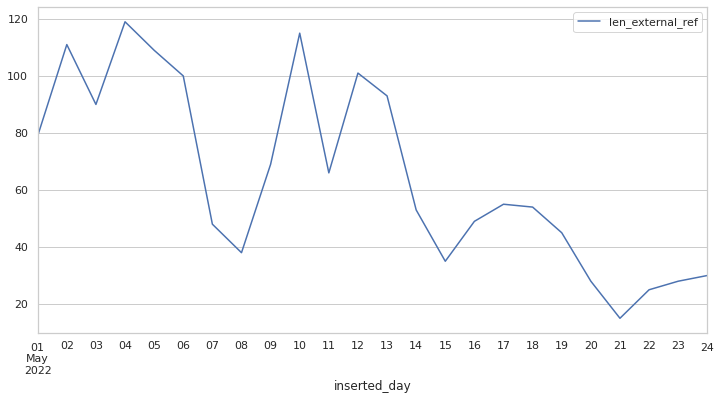

In [5]:
df_.plot("inserted_day", "len_external_ref")